In [1]:
import math


import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from CRU import CRUs, RyR_stationary, LCC_stationary
from RyR import test_RyR_cpu
from currents import get_ICa

In [2]:
@cuda.jit
def indexing_test(arr, flattened):
    x, y = cuda.grid(2)
    if x < arr.shape[0] and y < arr.shape[1]:
        val = get_ICa(flattened, x, y, arr.shape[0], arr.shape[1])
        arr[x,y] = val

In [9]:
arr = cuda.to_device(np.zeros((200,200), dtype=np.float32))
flattened = cuda.to_device(np.arange(796, dtype=np.float32))

In [10]:
indexing_test[(13,13),(16,16)](arr, flattened)
cuda.synchronize()

In [11]:
arr_h = arr.copy_to_host()

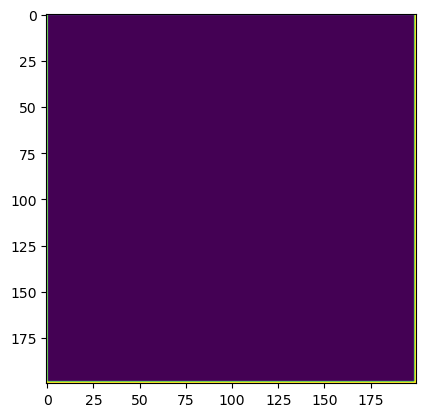

In [7]:
plt.imshow(arr_h)
plt.show()

In [2]:
cp = 10 * np.ones((200, 200), dtype=np.float32)

In [3]:
RyR = RyR_stationary(cp)

In [4]:
LCC = LCC_stationary(cp, 0.0)

In [5]:
cru_obj = CRUs(RyR, LCC, cp)

In [6]:
cru_obj.forward(0.0, 3e-3)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [7]:
cru_obj.RyR

array([[[9.52411890e-01, 3.55600491e-02, 0.00000000e+00, 1.20281382e-02],
        [9.51567531e-01, 3.64079624e-02, 1.01324222e-04, 1.19231939e-02],
        [9.51944351e-01, 3.60880047e-02, 5.98360784e-05, 1.19078159e-02],
        ...,
        [9.52251315e-01, 3.57336327e-02, 6.94190530e-05, 1.19456053e-02],
        [9.51341808e-01, 3.66516337e-02, 5.24257048e-05, 1.19541287e-02],
        [9.50799048e-01, 3.71779539e-02, 5.84790541e-06, 1.20171309e-02]],

       [[9.53363419e-01, 3.46629694e-02, 2.70614873e-05, 1.19465590e-02],
        [9.50352371e-01, 3.75905633e-02, 1.03206112e-05, 1.20467544e-02],
        [9.52748001e-01, 3.51601094e-02, 0.00000000e+00, 1.20918946e-02],
        ...,
        [9.51370060e-01, 3.66623998e-02, 1.27272389e-04, 1.18402839e-02],
        [9.52247679e-01, 3.57307643e-02, 6.33474265e-05, 1.19581819e-02],
        [9.51586187e-01, 3.66035588e-02, 7.32578483e-05, 1.17369890e-02]],

       [[9.52171028e-01, 3.59016135e-02, 8.91524687e-05, 1.18381977e-02],
        

In [12]:
dW_h = cru_obj.dW.copy_to_host()
rates_h = cru_obj.RyR_rates.copy_to_host()

RyR_test = test_RyR_cpu(RyR, rates_h, dW_h, 5e-3)

In [13]:
np.allclose(cru_obj.RyR, RyR_test)

True